<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Clustering/Clustering_Mall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Algorithms: A Detailed Exploration

Clustering is an unsupervised machine learning technique used to group data points into clusters such that data points within the same cluster are more similar to each other than to those in other clusters. Unlike supervised learning, there are no predefined labels or target variables; the algorithm discovers intrinsic groupings in the data.

### Key Concepts:

1.  **Similarity Measure**: How the distance or resemblance between data points is quantified (e.g., Euclidean distance, cosine similarity).
2.  **Centroid/Medoid**: A representative point of a cluster, often the mean or a central data point.
3.  **Evaluation Metrics**: Methods to assess the quality of clusters (e.g., Silhouette Score, Davies-Bouldin Index).

In this notebook, we will explore the following clustering algorithms in detail, covering their intuition, mathematical foundations, and practical application using the **Mall Customer Segmentation Data**:

*   **Partition-Based**: K-Means
*   **Hierarchical**: Agglomerative
*   **Density-Based**: DBSCAN
*   **Model-Based**: Gaussian Mixture Model (GMM)


## 1. Data Loading and Initial Exploration

First, let's load the Mall Customer Segmentation dataset and perform some initial exploration to understand its structure and features.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the dataset
data_url = 'https://raw.githubusercontent.com/rsys-adsingh/Machine-Learning/main/study/Clustering/Mall_Customers.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
display(df.head())

# Display basic information about the dataset
print(df.info())

# Display descriptive statistics
display(df.describe())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. Data Preprocessing and Visualization

Before applying clustering algorithms, it's essential to preprocess the data. This often involves handling categorical variables, scaling numerical features, and visualizing the data to gain insights into its structure.

First, we'll convert the 'Gender' column into a numerical format using one-hot encoding, and then we'll visualize the distribution of key features.

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Is_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


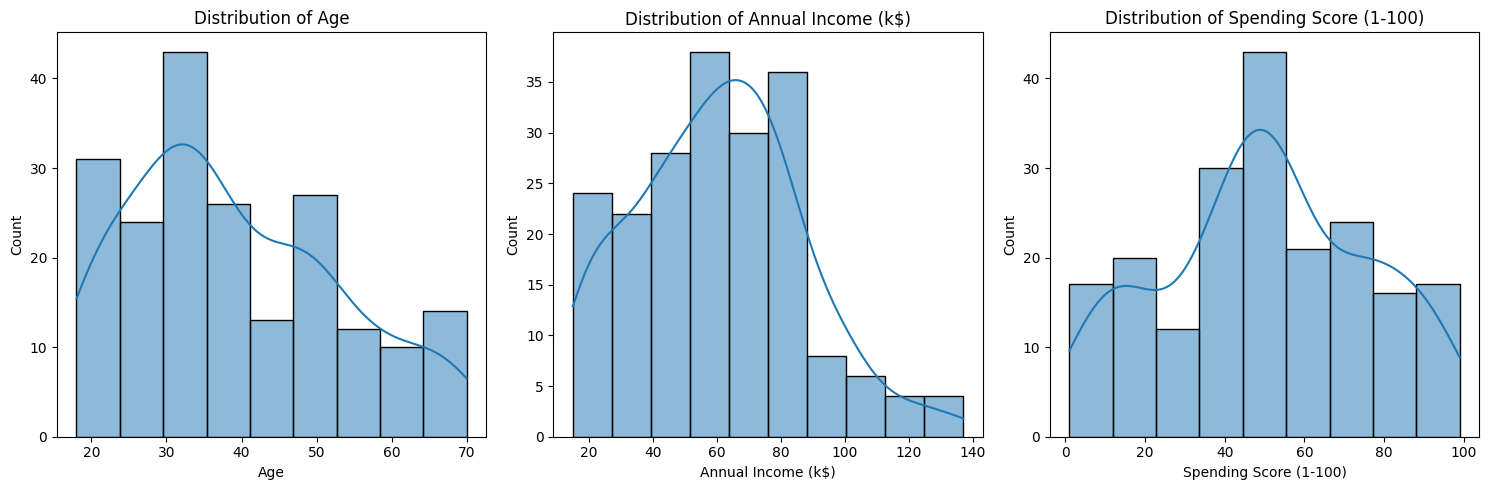

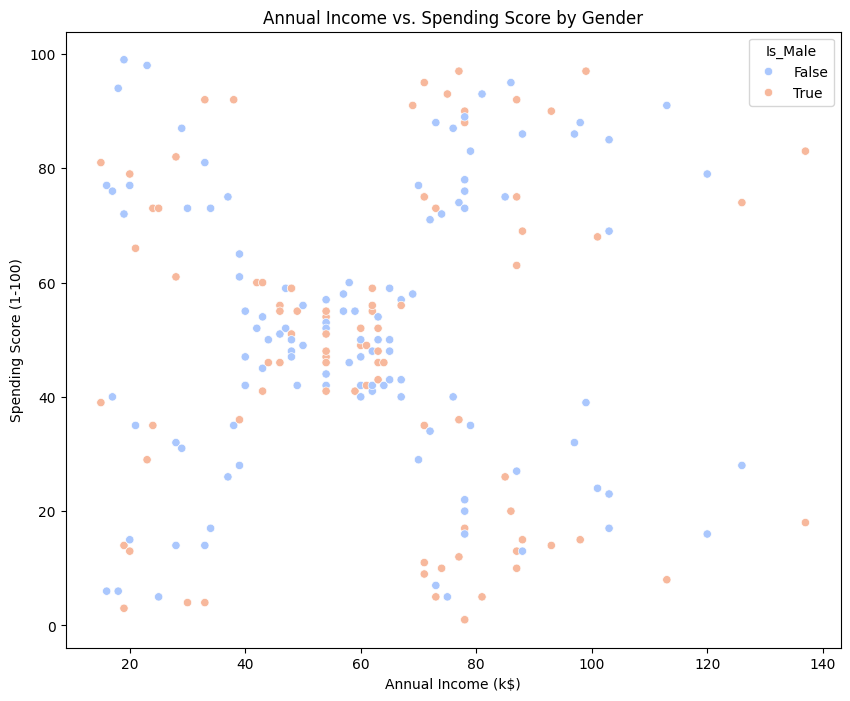

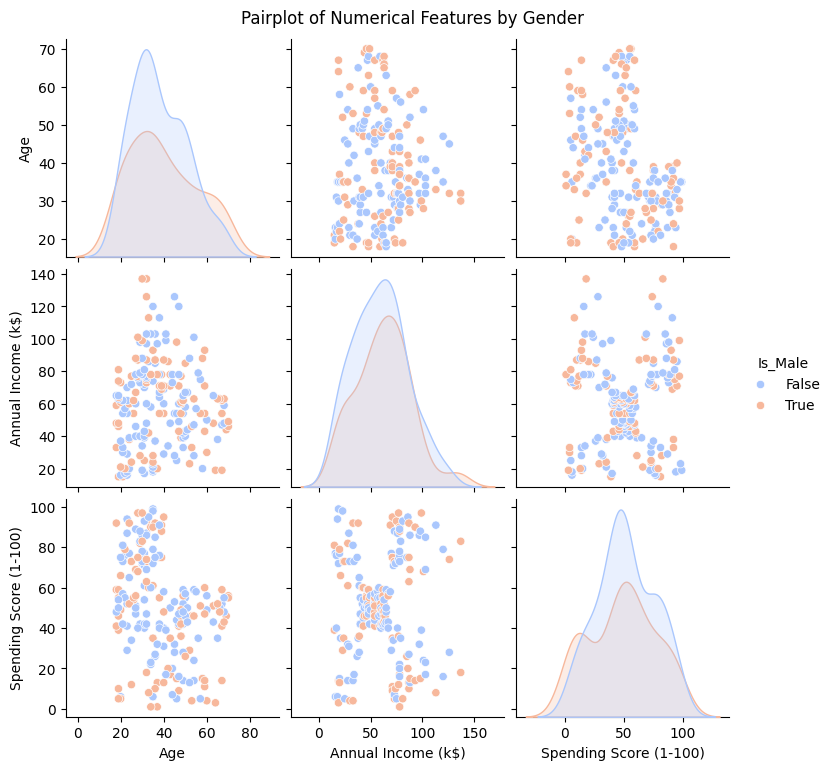

In [55]:
# One-hot encode the 'Gender' column
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True) # drop_first avoids multicollinearity

# Rename the new Gender column for clarity
df_encoded.rename(columns={'Gender_Male': 'Is_Male'}, inplace=True)

display(df_encoded.head())

# Visualize the distribution of numerical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_encoded['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df_encoded['Annual Income (k$)'], kde=True)
plt.title('Distribution of Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.histplot(df_encoded['Spending Score (1-100)'], kde=True)
plt.title('Distribution of Spending Score (1-100)')

plt.tight_layout()
plt.show()

# Visualize relationships between key features
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_encoded, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Is_Male', palette='coolwarm')
plt.title('Annual Income vs. Spending Score by Gender')
plt.show()

sns.pairplot(df_encoded[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']], hue='Is_Male', palette='coolwarm')
plt.suptitle('Pairplot of Numerical Features by Gender', y=1.02)
plt.show()

### Feature Scaling

Clustering algorithms that rely on distance metrics (like K-Means, Agglomerative, DBSCAN) are sensitive to the scale of the features. Features with larger values can dominate the distance calculations, leading to biased results. To prevent this, we will apply `StandardScaler` to normalize our numerical features (Age, Annual Income, Spending Score). We will not scale `CustomerID` as it's an identifier, nor `Is_Male` as it's already binary.

We will focus on `Annual Income (k$)` and `Spending Score (1-100)` for our primary clustering visualizations, as they showed the most prominent cluster structures.

In [56]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering. We'll mainly focus on Annual Income and Spending Score for initial clustering
# as they showed clear clusters in the scatter plot.
features_for_clustering = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df_encoded[features_for_clustering]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

display(X_scaled_df.head())

# You can also add the 'Is_Male' column back if you plan to use it in clustering
# X_scaled_df['Is_Male'] = df_encoded['Is_Male'].values

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 3. Partition-Based Clustering: K-Means

### 3.1 What is K-Means?
K-Means is one of the most popular unsupervised machine learning algorithms. It is a distance-based, partition-oriented algorithm that groups $n$ observations into $K$ pre-defined clusters.

### 3.2 Why K-Means?
It is favored for its simplicity, speed, and efficiency on large datasets. It provides a clear way to find local optimal solutions for grouping similar data points together.

### 3.3 What is K?
$K$ represents the number of clusters or groups the user wants to identify in the data. It is a hyperparameter that must be specified before the algorithm begins.

### 3.4 Centroid
A centroid is the arithmetic mean position of all the points in a cluster. It serves as the 'center' or representative point for that group.

### 3.5 Objective Function (WCSS)
The goal of K-Means is to minimize the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**:
$$ J = \sum_{i=1}^{n} \sum_{k=1}^{K} w_{ik} ||x_i - \mu_k||^2 $$
This function calculates the sum of squared distances between each data point and its assigned cluster centroid.

### 3.6 Algorithm Working
The algorithm follows an iterative process called **Lloyd's Algorithm**, which alternates between assigning points and updating centers.

### 3.7 Assignment Step
Each data point is assigned to the cluster with the nearest centroid based on the Euclidean distance:
$$ c^{(i)} := \text{arg min}_j ||x^{(i)} - \mu_j||^2 $$

### 3.8 Update Step
The centroids are moved to the mean of all points assigned to that cluster:
$$ \mu_j := \frac{\sum_{i=1}^n 1\{c^{(i)} = j\}x^{(i)}}{\sum_{i=1}^n 1\{c^{(i)} = j\}} $$

### 3.9 Convergence
The algorithm repeats the assignment and update steps until:
1. Centroids no longer change.
2. Assignments remain the same.
3. The maximum number of iterations is reached.

### 3.10 Choosing K
*   **WCSS**: Measures how compact the clusters are.
*   **Elbow Method**: We plot WCSS vs $K$. The 'elbow' is the point where the rate of decrease in WCSS drops sharply, indicating the optimal $K$.

### 3.11 K-Means++
*   **Random Initialization**: Choosing initial centroids randomly can lead to poor local optima.
*   **K-Means++**: An advanced initialization strategy that spreads out the initial centroids by picking points proportionally to their distance from existing centroids, leading to faster and better convergence.

### 3.12 Cluster Evaluation
*   **Inertia**: Lower inertia means more compact clusters.
*   **Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters (ranges from -1 to 1).

### 3.13 Time Complexity
The complexity is $O(n \cdot K \cdot I \cdot d)$, making it linear with respect to the number of data points $n$.

### 3.14 Advantages
*   Scales to large data.
*   Efficient and easy to interpret.
*   Guaranteed convergence.

### 3.15 Limitations
*   Sensitive to outliers.
*   Must specify $K$ manually.
*   Struggles with non-spherical shapes (e.g., elongated or nested clusters).

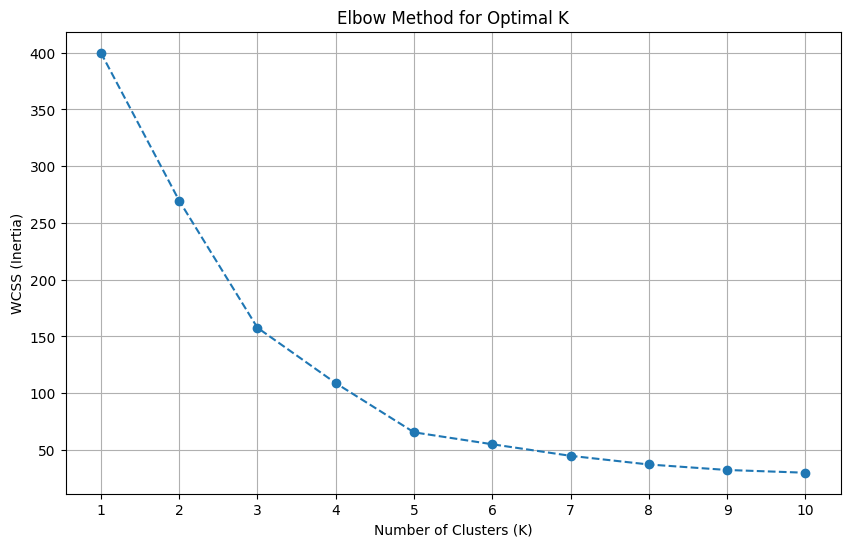

In [57]:
from sklearn.cluster import KMeans

# Select the features Annual Income and Spending Score for clustering for visualization purposes
X_2d = X_scaled_df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = [] # Within-Cluster Sum of Squares

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Applying K-Means with Optimal K

Based on the Elbow Method, we choose **K=5** as the optimal number of clusters. Let's now apply K-Means with 5 clusters to the `Annual Income (k$)` and `Spending Score (1-100)` features and visualize the clusters.

Inertia (WCSS):  65.57
Average Silhouette Score:  0.55


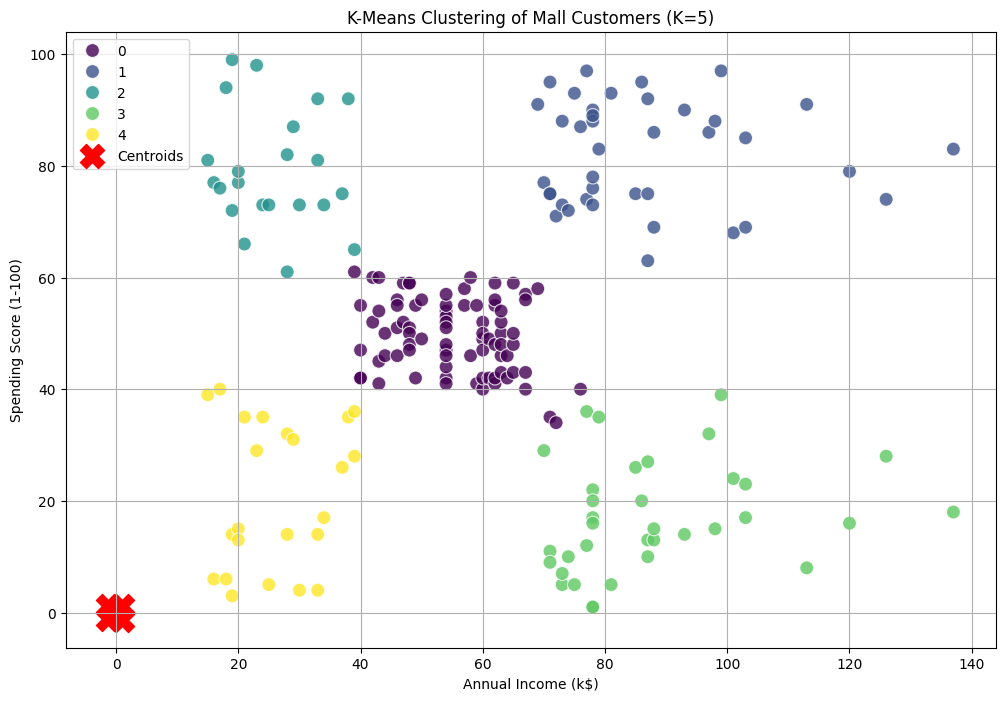

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 3.10 & 3.11: Applying K-Means with K=5 and K-Means++ initialization
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# 3.7 & 3.8: The fit_predict method executes the Assignment and Update steps iteratively
y_kmeans = kmeans.fit_predict(X_2d)

# Add labels to the dataframe
df_encoded['Cluster'] = y_kmeans

# 3.12: Evaluation Metrics
print(f"Inertia (WCSS): {kmeans.inertia_: .2f}")
sil_avg = silhouette_score(X_2d, y_kmeans)
print(f"Average Silhouette Score: {sil_avg: .2f}")

# Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)

# 3.4: Plotting the Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title('K-Means Clustering of Mall Customers (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Interpreting K-Means Clusters

Let's analyze the characteristics of each cluster to understand the different customer segments identified by K-Means.

In [59]:
# Group by cluster and calculate the mean of the original (unscaled) features
cluster_means = df_encoded.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

display(cluster_means)

# You can also look at the size of each cluster
display(df_encoded['Cluster'].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Is_Male
Cluster,,,,
0,42.716049,55.296296,49.518519,0.407407
1,32.692308,86.538462,82.128205,0.461538
2,25.272727,25.727273,79.363636,0.409091
3,41.114286,88.200000,17.114286,0.542857
4,45.217391,26.304348,20.913043,0.391304


,count
Cluster,
0,81
1,39
2,22
3,35
4,23


## 4. Hierarchical Clustering: Agglomerative

Hierarchical clustering algorithms build a hierarchy of clusters. **Agglomerative clustering** is a 'bottom-up' approach: each data point starts as its own cluster, and pairs of clusters are merged as one moves up the hierarchy.

### Intuition:

1.  **Start**: Each data point is considered a single cluster.
2.  **Merge**: At each step, the two closest clusters are merged into a new, larger cluster.
3.  **Repeat**: This process continues until all data points are grouped into a single cluster or a stopping criterion (e.g., a certain number of clusters) is met.

### Mathematical Foundation (Linkage Criteria):

The 'closeness' between clusters is determined by a **linkage criterion**. Common linkage criteria include:

*   **Ward's Method**: Minimizes the variance of the clusters being merged. It is generally used when the clusters are of roughly equal size.
*   **Single Linkage**: The distance between two clusters is the minimum distance between any point in the first cluster and any point in the second cluster.
*   **Complete Linkage**: The distance between two clusters is the maximum distance between any point in the first cluster and any point in the second cluster.
*   **Average Linkage**: The distance between two clusters is the average distance between all pairs of points in the two clusters.

### Dendrogram:

A **dendrogram** is a tree-like diagram that records the sequence of merges or splits and the distances at which they occurred. It helps in visualizing the hierarchy of clusters and determining the optimal number of clusters by cutting the dendrogram at an appropriate height.

Let's apply Agglomerative Clustering to our scaled `Annual Income (k$)` and `Spending Score (1-100)` features.

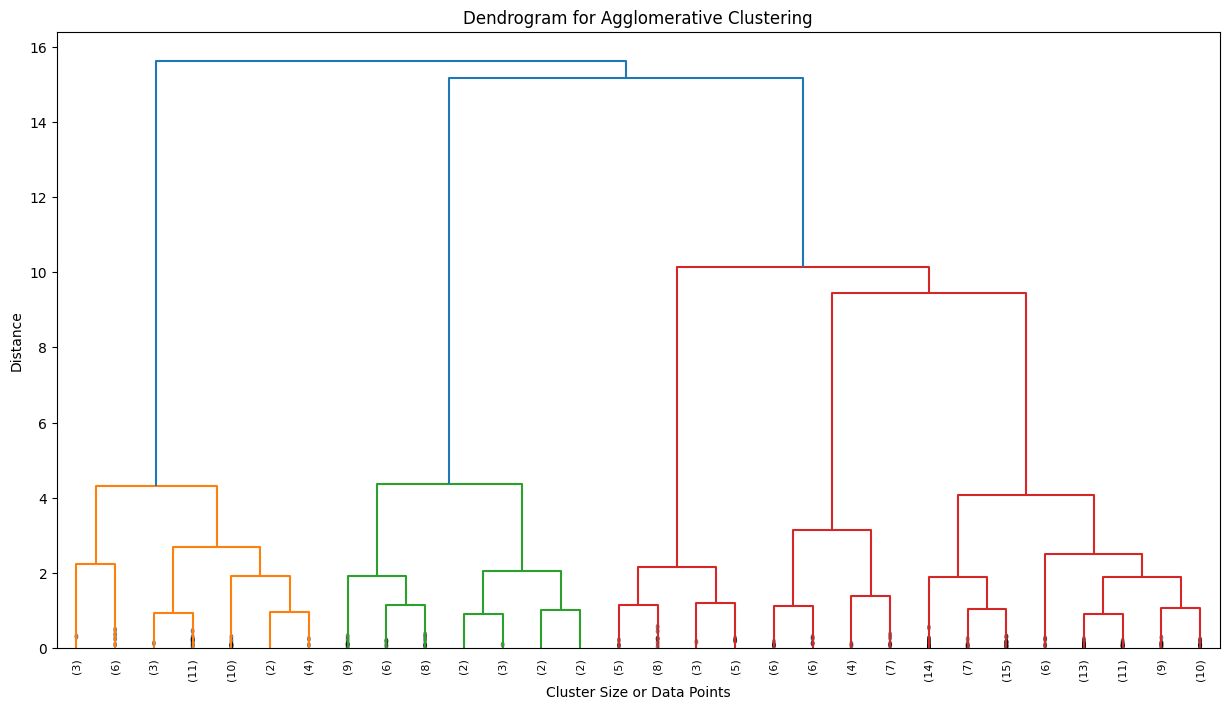

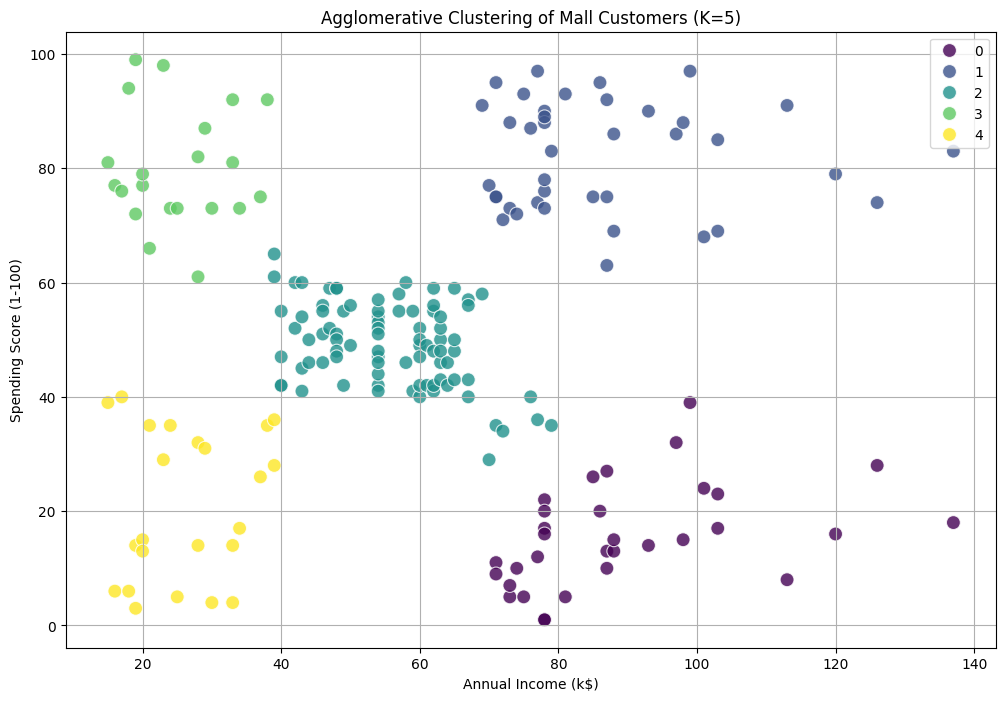

In [60]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# Generate the linkage matrix
Z = linkage(X_2d, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show only the last 30 merged clusters
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True,   # to get a cleaner plot
)
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Cluster Size or Data Points')
plt.ylabel('Distance')
plt.show()

# From the dendrogram, we can observe distinct clusters. Let's choose 5 clusters as before.
n_clusters_agg = 5

# Apply Agglomerative Clustering
# Removed affinity='euclidean' as it's not a valid parameter when linkage='ward'
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
df_encoded['Agglomerative_Cluster'] = agg_clustering.fit_predict(X_2d)

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglomerative_Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)
plt.title(f'Agglomerative Clustering of Mall Customers (K={n_clusters_agg})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Interpreting Agglomerative Clusters

Let's examine the characteristics of the clusters identified by Agglomerative Clustering and compare them with K-Means.

In [61]:
from sklearn.cluster import AgglomerativeClustering

# Group by Agglomerative cluster and calculate the mean of the original (unscaled) features

# Check if 'Agglomerative_Cluster' column exists. If not, re-run the clustering step.
if 'Agglomerative_Cluster' not in df_encoded.columns:
    print("Column 'Agglomerative_Cluster' not found. Re-running Agglomerative Clustering.")
    # Assuming X_2d and n_clusters_agg are available from previous cells.
    # If not, these lines might need to be adapted or preceding cells executed.
    n_clusters_agg = 5 # Defaulting to 5 clusters as determined previously
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
    df_encoded['Agglomerative_Cluster'] = agg_clustering.fit_predict(X_2d)

agg_cluster_means = df_encoded.groupby('Agglomerative_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

display(agg_cluster_means)

# You can also look at the size of each cluster
display(df_encoded['Agglomerative_Cluster'].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Is_Male
Agglomerative_Cluster,,,,
0,41.000000,89.406250,15.593750,0.562500
1,32.692308,86.538462,82.128205,0.461538
2,42.482353,55.811765,49.129412,0.400000
3,25.333333,25.095238,80.047619,0.428571
4,45.217391,26.304348,20.913043,0.391304


,count
Agglomerative_Cluster,
0,32
1,39
2,85
3,21
4,23


## 5. Density-Based Clustering: DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a non-parametric clustering algorithm that groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions. Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand and can discover clusters of arbitrary shapes.

### Intuition:

1.  **Core Point**: A point is a core point if there are at least `min_samples` (a parameter) points within a distance `eps` (epsilon, another parameter) from it (including itself).
2.  **Border Point**: A point is a border point if it is not a core point but lies within the `eps` distance of a core point.
3.  **Noise Point (Outlier)**: A point that is neither a core point nor a border point.

Clusters are then formed by connecting core points that are within `eps` distance of each other, and including their border points.

### Mathematical Foundation:

DBSCAN relies on two main parameters:

*   **`eps` (epsilon)**: The maximum distance between two samples for one to be considered as in the neighborhood of the other. Also known as the radius.
*   **`min_samples`**: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself.

The algorithm iteratively processes data points, marking them as core, border, or noise, and expanding clusters from core points.

### Determining Optimal Parameters (`eps`, `min_samples`):

Choosing appropriate `eps` and `min_samples` is crucial. A common approach for `eps` is to use the **K-distance graph**. For each point, calculate the distance to its k-th nearest neighbor (where k is `min_samples`). Sort these distances in ascending order and plot them. The 'elbow' point in this graph can suggest a suitable `eps` value.

Let's apply DBSCAN to our scaled `Annual Income (k$)` and `Spending Score (1-100)` features.

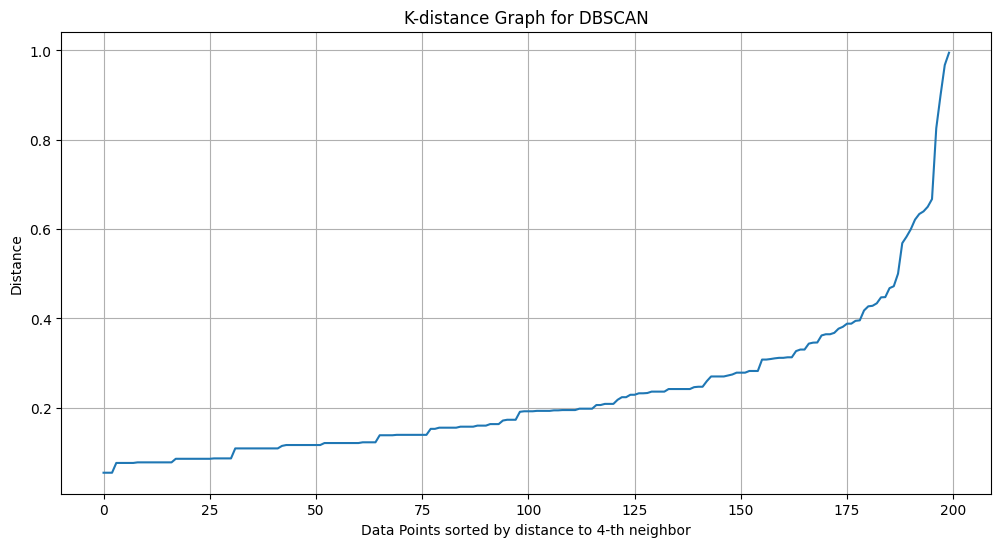

Estimated number of DBSCAN clusters: 4
Number of noise points: 14


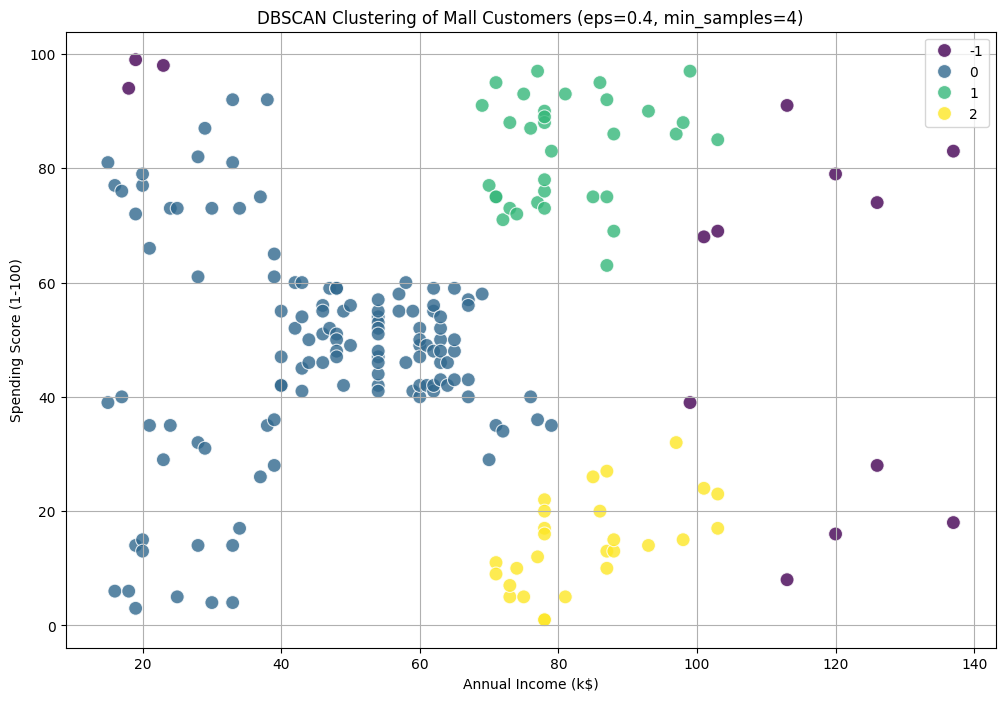

In [62]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np # Import numpy

# --- Step 1: Determine optimal `eps` using the K-distance graph ---
# For min_samples, a common heuristic is 2 * dimensionality of the data.
# Here, we're using 2 features (Annual Income, Spending Score), so min_samples = 4.
min_samples = 4 # for 2D data, 2*D is a common heuristic, D=2 => 4

# Calculate the distance to the k-th nearest neighbor for each point
neigh = NearestNeighbors(n_neighbors=min_samples)
ners = neigh.fit(X_2d)
distances, indices = ners.kneighbors(X_2d)

# Sort the distances (specifically, the distance to the k-th neighbor)
distances = np.sort(distances[:, min_samples-1], axis=0)

# Plot the K-distance graph
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN')
plt.xlabel('Data Points sorted by distance to {}-th neighbor'.format(min_samples))
plt.ylabel('Distance')
plt.grid(True)
plt.show()

# --- Step 2: Apply DBSCAN with chosen parameters ---
# Based on the elbow in the K-distance graph, let's choose an eps value.
# (Visually estimate an elbow point from the graph)
# For demonstration, let's pick a value. This often requires visual inspection.
# A reasonable eps from the elbow plot usually falls around 0.3 to 0.5 for this dataset.
eps_val = 0.4 # This value is an estimate based on typical elbow points for this dataset

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
df_encoded['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d)

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(df_encoded['DBSCAN_Cluster'])) - (1 if -1 in df_encoded['DBSCAN_Cluster'] else 0)
print(f"Estimated number of DBSCAN clusters: {n_clusters_}")
print(f"Number of noise points: {(df_encoded['DBSCAN_Cluster'] == -1).sum()}")

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)
plt.title(f'DBSCAN Clustering of Mall Customers (eps={eps_val}, min_samples={min_samples})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Interpreting DBSCAN Clusters

Let's analyze the characteristics of the clusters identified by DBSCAN, paying attention to the noise points (-1 label).

In [63]:
from sklearn.cluster import DBSCAN
import numpy as np

# Ensure DBSCAN_Cluster exists in df_encoded
if 'DBSCAN_Cluster' not in df_encoded.columns:
    print("DBSCAN_Cluster column not found. Applying DBSCAN...")
    # Use the parameters defined in the previous cell
    eps_val = 0.4
    min_samples = 4
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
    df_encoded['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d)

# Group by DBSCAN cluster and calculate the mean of the original (unscaled) features
# We filter out noise points (label -1) for the mean calculation to see cluster profiles
dbscan_cluster_means = df_encoded[df_encoded['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

print("Mean values for each DBSCAN cluster (excluding noise):")
display(dbscan_cluster_means)

# Look at the size of each cluster, including noise points (-1)
print("\nCluster sizes (including -1 as noise):")
display(df_encoded['DBSCAN_Cluster'].value_counts().sort_index())

Mean values for each DBSCAN cluster (excluding noise):


,Age,Annual Income (k$),Spending Score (1-100),Is_Male
DBSCAN_Cluster,,,,
0,40.396825,46.158730,47.992063,0.412698
1,32.727273,81.060606,83.000000,0.454545
2,41.259259,83.925926,14.444444,0.592593



Cluster sizes (including -1 as noise):


,count
DBSCAN_Cluster,
-1,14
0,126
1,33
2,27


## 6. Model-Based Clustering: Gaussian Mixture Model (GMM)

Gaussian Mixture Models (GMMs) are probabilistic models that assume data points are generated from a mixture of several Gaussian distributions with unknown parameters. GMMs are a "soft" clustering approach, meaning each data point is assigned a probability of belonging to each cluster, rather than a single, hard assignment.

### Intuition:

Imagine that your data points were generated by a set of different Gaussian (normal) distributions. The goal of a GMM is to find the parameters (mean, variance, and weight) of each of these hidden Gaussian distributions that best explain the observed data. Each Gaussian distribution represents a cluster.

### Mathematical Foundation (Expectation-Maximization):

GMMs are typically fitted using the **Expectation-Maximization (EM) algorithm**:

1.  **Expectation (E-step)**: Given the current parameters for each Gaussian component, calculate the probability that each data point belongs to each component (i.e., its membership weight for each cluster).
    $$ \gamma(z_{nk}) = \frac{\pi_k \mathcal{N}(x_n | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(x_n | \mu_j, \Sigma_j)} $$
    Where $\gamma(z_{nk})$ is the posterior probability that data point $x_n$ belongs to cluster $k$.

2.  **Maximization (M-step)**: Update the parameters (mean $\mu_k$, covariance $\Sigma_k$, and mixing coefficient $\pi_k$) for each Gaussian component based on the data points' current cluster memberships.
    *   **Mean**: Updated to the weighted mean of the data points, where weights are the responsibilities from the E-step.
    *   **Covariance**: Updated to the weighted covariance of the data points.
    *   **Mixing Coefficient**: Updated to the average responsibility for each component.

3.  **Repeat**: These two steps are iterated until convergence (the parameters no longer change significantly).

### Determining the Optimal Number of Components:

Like K-Means, GMM requires specifying the number of components (clusters) `K`. We can use information criteria such as the **Bayesian Information Criterion (BIC)** or **Akaike Information Criterion (AIC)** to select the best `K`. Lower BIC or AIC values generally indicate a better model.

Let's apply GMM to our scaled `Annual Income (k$)` and `Spending Score (1-100)` features.

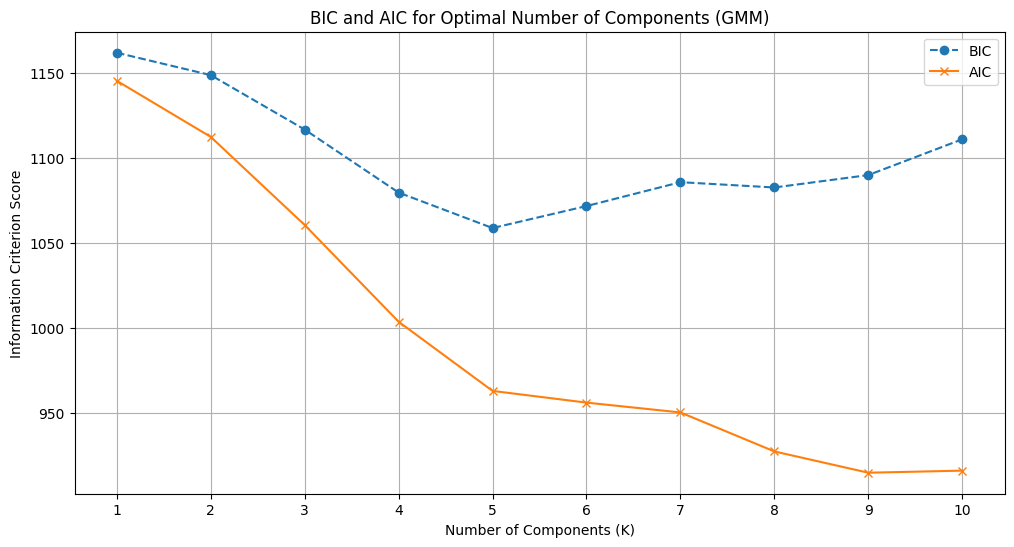

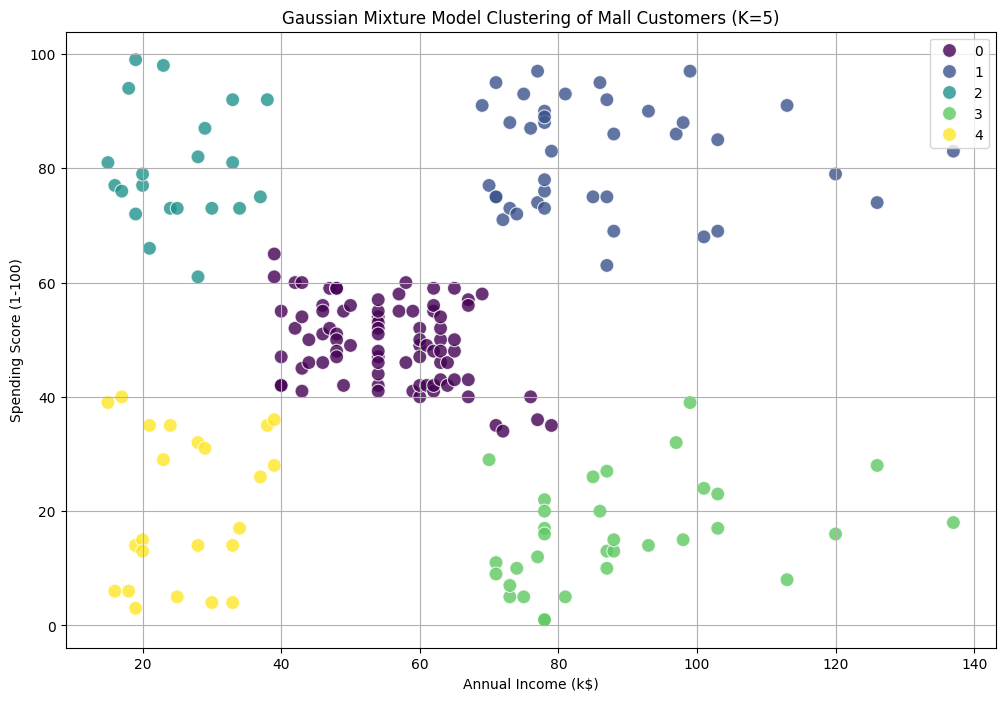

In [64]:
from sklearn.mixture import GaussianMixture
import numpy as np

# --- Step 1: Determine optimal number of components (K) using BIC/AIC ---
bic = []
aic = []

# Try different numbers of components from 1 to 10
for i in range(1, 11):
    gmm = GaussianMixture(n_components=i, random_state=42, n_init=10)
    gmm.fit(X_2d)
    bic.append(gmm.bic(X_2d))
    aic.append(gmm.aic(X_2d))

# Plot BIC and AIC scores
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), bic, marker='o', linestyle='--', label='BIC')
plt.plot(range(1, 11), aic, marker='x', linestyle='-', label='AIC')
plt.title('BIC and AIC for Optimal Number of Components (GMM)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Information Criterion Score')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()

# --- Step 2: Apply GMM with the optimal number of components ---
# From the plot, the optimal K will be where BIC/AIC is minimized. This often points to 5 or 6 for this dataset.
# Let's choose K=5 for consistency with K-Means and Agglomerative.
n_components_gmm = 5 # Adjust based on visual inspection of the BIC/AIC plot

gmm = GaussianMixture(n_components=n_components_gmm, random_state=42, n_init=10)
y_gmm = gmm.fit_predict(X_2d)

# Add the cluster labels to the original (encoded) DataFrame
df_encoded['GMM_Cluster'] = y_gmm

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='GMM_Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)
plt.title(f'Gaussian Mixture Model Clustering of Mall Customers (K={n_components_gmm})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Interpreting GMM Clusters

Let's analyze the characteristics of the clusters identified by Gaussian Mixture Model and compare them with the previous algorithms.

In [65]:
# Group by GMM cluster and calculate the mean of the original (unscaled) features
gmm_cluster_means = df_encoded.groupby('GMM_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

display(gmm_cluster_means)

# You can also look at the size of each cluster
display(df_encoded['GMM_Cluster'].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Is_Male
GMM_Cluster,,,,
0,42.714286,55.642857,49.369048,0.404762
1,32.692308,86.538462,82.128205,0.461538
2,25.333333,25.095238,80.047619,0.428571
3,40.454545,88.818182,16.000000,0.545455
4,45.217391,26.304348,20.913043,0.391304


,count
GMM_Cluster,
0,84
1,39
2,21
3,33
4,23


## 7. Model Evaluation and Comparison

To objectively compare the performance of our clustering algorithms, we use internal evaluation metrics since we do not have ground-truth labels.

### Metrics Used:
1. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Values range from -1 to 1; higher is better.
2. **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar one. Lower values indicate better separation between clusters.

In [66]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

metrics = []

# K-Means
metrics.append({
    'Model': 'K-Means',
    'Silhouette': silhouette_score(X_2d, df_encoded['Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d, df_encoded['Cluster'])
})

# Agglomerative
metrics.append({
    'Model': 'Agglomerative',
    'Silhouette': silhouette_score(X_2d, df_encoded['Agglomerative_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d, df_encoded['Agglomerative_Cluster'])
})

# DBSCAN (Filtering out noise -1 for metrics calculation)
mask = df_encoded['DBSCAN_Cluster'] != -1
metrics.append({
    'Model': 'DBSCAN',
    'Silhouette': silhouette_score(X_2d[mask], df_encoded.loc[mask, 'DBSCAN_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d[mask], df_encoded.loc[mask, 'DBSCAN_Cluster'])
})

# GMM
metrics.append({
    'Model': 'GMM',
    'Silhouette': silhouette_score(X_2d, df_encoded['GMM_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d, df_encoded['GMM_Cluster'])
})

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Model,Silhouette,Davies-Bouldin
0,K-Means,0.554657,0.572236
1,Agglomerative,0.553809,0.577862
2,DBSCAN,0.457570,0.654560
3,GMM,0.553689,0.576010


### Detailed Model Comparison and Performance Analysis

| Algorithm | Logic | Best For | Observation on Mall Dataset |
| :--- | :--- | :--- | :--- |
| **K-Means** | Centroid-based | Spherical, well-separated clusters | Produced very clean, interpretable segments (K=5). |
| **Agglomerative** | Hierarchy-based | Understanding nested relationships | Very similar results to K-Means; useful for dendrogram visualization. |
| **DBSCAN** | Density-based | Arbitrary shapes & outlier detection | Identified noise points; combined smaller groups into one large dense cluster. |
| **GMM** | Probabilistic | Ellipsoid clusters & overlapping data | Offers "soft" assignment; results closely mirror K-Means but are more flexible. |

/tmp/ipykernel_2664/2054331621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Silhouette', data=df_metrics, palette='magma')


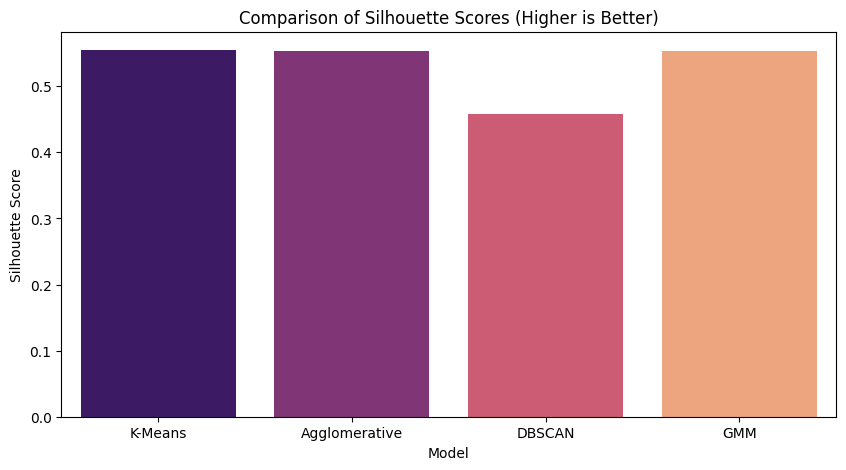

In [67]:
# Visualizing the Silhouette Scores for Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Silhouette', data=df_metrics, palette='magma')
plt.title('Comparison of Silhouette Scores (Higher is Better)')
plt.ylabel('Silhouette Score')
plt.show()

## 8. Overall Conclusion

In this analysis, we applied four distinct clustering paradigms to the Mall Customer dataset.

* **Primary Insight**: The most consistent finding across K-Means, Agglomerative, and GMM was the identification of **5 distinct customer segments** based on Annual Income and Spending Score. These segments include 'High Income/High Spenders', 'High Income/Low Spenders', 'Average Income/Average Spenders', 'Low Income/High Spenders', and 'Low Income/Low Spenders'.
* **Hyperparameter Tuning**: We successfully used the Elbow Method for K-Means, Dendrograms for Agglomerative, K-distance plots for DBSCAN, and BIC/AIC for GMM to select optimal parameters.
* **Performance**: K-Means and GMM provided the most actionable insights for this specific dataset, while DBSCAN proved valuable for identifying anomalous customers (outliers).

This segmentation provides a solid foundation for targeted marketing strategies, such as offering loyalty rewards to High Spenders or targeted promotions to High-Income/Low-Spenders.